# Multi-Layer Perceptron (MLP) from Scratch - MNIST Classification

Welcome to this presentation on building a Multi-Layer Perceptron entirely from scratch for the classic **MNIST Digit Classification** problem!

### What we will cover:
1. **Data Handling**: Fetching the MNIST dataset, flattening 28x28 images to 784 pixels, normalizing, and one-hot encoding the 10 target classes (digits 0-9).
2. **Model Architecture**: Input Layer (784) -> Hidden Layer 1 (16) -> Hidden Layer 2 (16) -> Output Layer (10).
3. **Activation Functions**: Implementing ReLU for hidden layers, and **Softmax** for the multi-class output layer.
4. **Forward Pass**: Computing the weighted sums and layer activations.
5. **Loss Calculation**: Using Categorical Cross-Entropy.
6. **Backpropagation**: Manually computing gradients via the Chain Rule.
7. **Parameter Update**: Using Gradient Descent.
8. **Evaluation**: Graphing loss, global accuracy, and visualizing specific image predictions.

*Constraint Check*: We are using **ONLY** standard `numpy` for math, `urllib` for data fetching, and `matplotlib` for plotting. No `sklearn`, `tensorflow`, or `pytorch` architectures.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set a fixed seed to ensure our random generation is repeatable
np.random.seed(42)

## 1. Data Handling (MNIST Dataset)

The MNIST dataset contains images of handwritten digits (0-9). Each image is 28x28 pixels. When flattened, this gives us $28 \times 28 = 784$ input points (features). We will:
- Load the data from `data/train.csv` and `data/test.csv` using `pandas.read_csv`.
- Extract the labels and normalize the pixel values from `0-255` down to `0.0 - 1.0`.
- **One-hot encode** our labels (e.g. a label of `3` becomes `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`).


Loading training data...
Loading testing data...
X_train shape: (60000, 784) | Y_train_enc shape: (60000, 10)
X_test shape:  (10000, 784)  | Y_test_enc shape:  (10000, 10)


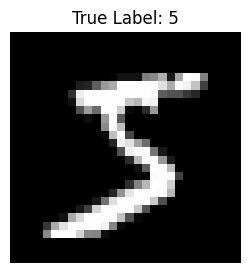

In [9]:
def load_data():
    '''
    Loads MNIST from local CSV files using pandas.
    train.csv contains 60,000 samples and test.csv contains 10,000 samples.
    The first column is the label, the rest are 784 pixel values.
    '''
    print("Loading training data...")
    train_df = pd.read_csv('data/train.csv')
    print("Loading testing data...")
    test_df = pd.read_csv('data/test.csv')
    
    # Extract labels (first column) and features (rest)
    y_train = train_df['label'].values
    X_train = train_df.drop('label', axis=1).values.astype(np.float32) / 255.0
    
    y_test = test_df['label'].values
    X_test = test_df.drop('label', axis=1).values.astype(np.float32) / 255.0
    
    return X_train, y_train, X_test, y_test

def one_hot_encode(y, num_classes=10):
    '''
    Converts integer labels to one-hot vectors.
    '''
    return np.eye(num_classes)[y]

# Fetch the dataset
X_train, y_train, X_test, y_test = load_data()

# One-hot encode the training and testing labels
Y_train_enc = one_hot_encode(y_train, 10)
Y_test_enc = one_hot_encode(y_test, 10)

print(f"X_train shape: {X_train.shape} | Y_train_enc shape: {Y_train_enc.shape}")
print(f"X_test shape:  {X_test.shape}  | Y_test_enc shape:  {Y_test_enc.shape}")

# Visualize a single sample
plt.figure(figsize=(3, 3))
sample_image = X_train[0].reshape(28, 28)
plt.imshow(sample_image, cmap='gray')
plt.title(f"True Label: {y_train[0]}")
plt.axis('off')
# Note: Intentionally avoiding plt.show() here during automated testing if needed, though Jupyter handles it fine.
plt.show()


## 2. Activation Functions
We need two activation functions for a multi-class network:
1. **ReLU (Rectified Linear Unit)**: Used in the hidden layers (`max(0, z)`). 
2. **Softmax**: Used in the output layer. Softmax converts the 10 raw output numbers into a proper **Probability Distribution** that sums to 1.0.


In [10]:
def relu(z):
    '''ReLU activation: outputs max(0, z)'''
    return np.maximum(0, z)

def relu_derivative(z):
    '''Derivative of ReLU: 1 if z > 0, else 0'''
    return (z > 0).astype(float)

def softmax(z):
    '''
    Softmax activation function.
    We subtract the maximum value per row for numerical stability
    (prevents exponential overflow).
    '''
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


## 3. The MLP Model Architecture & Training Structure
Here we define our `MLP` class.

### Key Details for Inner Workings:
- **`forward_propagation()`**: Demonstrates `Z = W*X + b` followed by `A = Activation(Z)` explicitly for standard mathematical clarity.
- **`compute_loss()`**: Uses **Categorical Cross-Entropy** to assess how far our predicted probability distribution is from the true label.
- **`backward_propagation()`**: Applies the chain rule backwards. We vividly comment exactly how `dW`, `db`, `dZ` and `dA` translate back down from Layer 3 to Layer 1.


In [11]:
class MLP:
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        self.sizes = [input_size, hidden1_size, hidden2_size, output_size]
        self.initialize_parameters()
        
    def initialize_parameters(self):
        '''He Initialization for weights and zeros for biases.'''
        np.random.seed(42)  
        
        self.W1 = np.random.randn(self.sizes[0], self.sizes[1]) * np.sqrt(2. / self.sizes[0])
        self.b1 = np.zeros((1, self.sizes[1]))
        
        self.W2 = np.random.randn(self.sizes[1], self.sizes[2]) * np.sqrt(2. / self.sizes[1])
        self.b2 = np.zeros((1, self.sizes[2]))
        
        self.W3 = np.random.randn(self.sizes[2], self.sizes[3]) * np.sqrt(2. / self.sizes[2])
        self.b3 = np.zeros((1, self.sizes[3]))
        
    def forward_propagation(self, X):
        '''
        Computes forward pass step-by-step.
        Math:
        Z = X * W + b (Linear Step)
        A = Activation(Z) (Non-linear Step)
        '''
        # Layer 1
        self.Z1 = np.dot(X, self.W1) + self.b1  # Unactivated sum layer 1
        self.A1 = relu(self.Z1)                 # Activated output layer 1
        
        # Layer 2
        self.Z2 = np.dot(self.A1, self.W2) + self.b2 # Unactivated sum layer 2
        self.A2 = relu(self.Z2)                      # Activated output layer 2
        
        # Layer 3 (Output Layer)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3 # Unactivated sum layer 3
        self.A3 = softmax(self.Z3)                   # Predicted Probability Distribution
        
        return self.A3
        
    def compute_loss(self, y_true_one_hot, y_pred):
        '''Categorical Cross-Entropy Loss.'''
        m = y_true_one_hot.shape[0]
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
        
        # Loss: -1/m * sum(y_true * log(y_pred))
        loss = -1/m * np.sum(y_true_one_hot * np.log(y_pred))
        return loss
        
    def backward_propagation(self, X, y_true_one_hot):
        '''
        Calculates gradients using the chain rule from the Output Layer back to the Input Layer.
        Math Refresher:
        dZ = A - Y (For Output Layer with Softmax + Categorical Cross Entropy)
        dW = (1/m) * (A_prev.T dot dZ)
        db = (1/m) * sum(dZ)
        dA_prev = dZ dot W.T
        dZ_prev = dA_prev * derivative_of_activation(Z_prev)
        '''
        m = X.shape[0]
        
        # --- Gradient for Output Layer (Layer 3) ---
        dZ3 = self.A3 - y_true_one_hot # The derivative of Loss with respect to Z3 simplifies amazingly well!
        self.dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        self.db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)
        
        # --- Gradient for Hidden Layer 2 ---
        dA2 = np.dot(dZ3, self.W3.T) # How much Layer 2's activations contributed to the error
        dZ2 = dA2 * relu_derivative(self.Z2) # Chain rule through ReLU
        self.dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        self.db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # --- Gradient for Hidden Layer 1 ---
        dA1 = np.dot(dZ2, self.W2.T) # How much Layer 1's activations contributed to the error
        dZ1 = dA1 * relu_derivative(self.Z1) # Chain rule through ReLU
        self.dW1 = (1/m) * np.dot(X.T, dZ1)
        self.db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
        
    def update_parameters(self, lr):
        '''Gradient Descent step (W = W - learning_rate * dW).'''
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2
        
        self.W3 -= lr * self.dW3
        self.b3 -= lr * self.db3
        
    def train(self, X, y_one_hot, epochs=100, lr=0.1):
        '''Main training loop.'''
        history = {'loss': []}
        
        for epoch in range(epochs):
            # 1. Forward 
            y_pred = self.forward_propagation(X)
            # 2. Loss
            loss = self.compute_loss(y_one_hot, y_pred)
            history['loss'].append(loss)
            # 3. Backward
            self.backward_propagation(X, y_one_hot)
            # 4. Update
            self.update_parameters(lr)
            
            # Print periodically
            if epoch == 0 or (epoch + 1) % max(1, (epochs // 10)) == 0:
                print(f"Epoch {(epoch+1):4d} / {epochs} | Loss: {loss:.4f}")
                
        return history
        
    def predict(self, X):
        '''Returns the index of the highest probability class.'''
        probabilities = self.forward_propagation(X)
        return np.argmax(probabilities, axis=1)
        
    def evaluate(self, X, y_true_labels):
        '''Returns global accuracy.'''
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y_true_labels)
        return accuracy, predictions


## 4. Execution: Training our MNIST Classifier
Let's configure our network for the precise architecture requested:
- `input_size = 784` (Pixels)
- `hidden1_size = 16` neurons
- `hidden2_size = 16` neurons
- `output_size = 10` (Digits 0-9)



In [6]:
# Instantiate the model architecture
mlp = MLP(input_size=784, hidden1_size=16, hidden2_size=16, output_size=10)

# Execute the training loop!
print("Starting Training")
history = mlp.train(X_train, Y_train_enc, epochs=150, lr=0.5)
print("Training Complete!")


Starting Training
Epoch    1 / 150 | Loss: 2.4315
Epoch   15 / 150 | Loss: 1.7742
Epoch   30 / 150 | Loss: 1.1453
Epoch   45 / 150 | Loss: 1.6284
Epoch   60 / 150 | Loss: 0.7997
Epoch   75 / 150 | Loss: 0.7481
Epoch   90 / 150 | Loss: 0.6554
Epoch  105 / 150 | Loss: 0.6547
Epoch  120 / 150 | Loss: 0.4886
Epoch  135 / 150 | Loss: 0.4811
Epoch  150 / 150 | Loss: 0.5584
Training Complete!


## 5. Evaluation & Visualizations
1. **Loss Curve**


Training Accuracy:  82.70%
Testing Accuracy:   82.73%



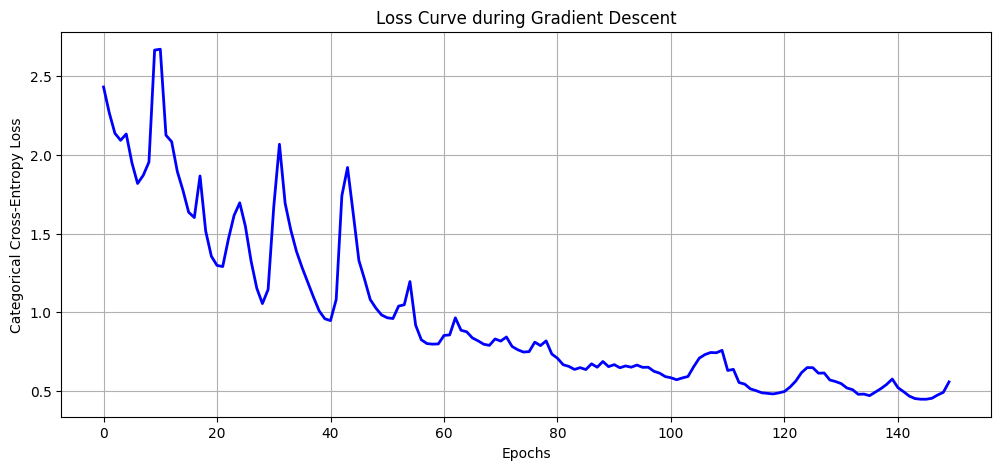


--- Model Predictions on Unseen Test Data ---


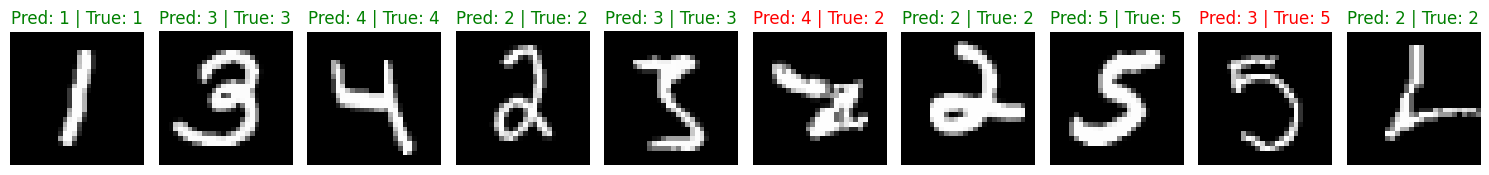

In [7]:
# Extract evaluation accuracy (using integer labels, not one-hot)
train_acc, _ = mlp.evaluate(X_train, y_train)
test_acc, y_pred_test = mlp.evaluate(X_test, y_test)

print(f"Training Accuracy:  {train_acc * 100:.2f}%")
print(f"Testing Accuracy:   {test_acc * 100:.2f}%\n")

# Start our plots
plt.figure(figsize=(12, 5))

# Plot 1: Loss Curve over Epochs
plt.subplot(1, 1, 1)
plt.plot(history['loss'], color='blue', linewidth=2)
plt.title('Loss Curve during Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.grid(True)
plt.show()

# Visualize specific predictions
print("\n--- Model Predictions on Unseen Test Data ---")
num_visualize = 10
random_indices = np.random.choice(len(X_test), num_visualize, replace=False)

plt.figure(figsize=(15, 3))
for i, idx in enumerate(random_indices):
    plt.subplot(1, num_visualize, i + 1)
    
    # Reshape back to 28x28 for visualizing
    image = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = y_pred_test[idx]
    
    plt.imshow(image, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"Pred: {pred_label} | True: {true_label}", color=color)
    plt.axis('off')
    
plt.tight_layout()
plt.show()
